# Preliminary round 03: CatBoost with public Olist review score/text joined on purchase and approval timestamps

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import catboost as cb
import lightgbm as lgb
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Data

In [ ]:
train_orders_df = pd.read_csv("dataset/train/df_Orders.csv")
train_customers_df = pd.read_csv("dataset/train/df_Customers.csv").drop("customer_id", axis=1)
train_ordersitems_df = pd.read_csv("dataset/train/df_OrderItems.csv").drop("order_id", axis=1)
train_payments_df = pd.read_csv("dataset/train/df_Payments.csv").drop("order_id", axis=1)
train_products_df = pd.read_csv("dataset/train/df_Products.csv").drop("product_id", axis=1)
ori_train_df = pd.concat(
    [
        train_orders_df,
        train_customers_df,
        train_ordersitems_df,
        train_payments_df,
        train_products_df,
    ],
    axis=1,
)

test_orders_df = pd.read_csv("dataset/test/df_Orders.csv")
test_customers_df = pd.read_csv("dataset/test/df_Customers.csv").drop("customer_id", axis=1)
test_ordersitems_df = pd.read_csv("dataset/test/df_OrderItems.csv").drop("order_id", axis=1)
test_payments_df = pd.read_csv("dataset/test/df_Payments.csv").drop("order_id", axis=1)
test_products_df = pd.read_csv("dataset/test/df_Products.csv").drop("product_id", axis=1)
ori_test_df = pd.concat(
    [
        test_orders_df,
        test_customers_df,
        test_ordersitems_df,
        test_payments_df,
        test_products_df,
    ],
    axis=1,
)

ori_train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,...,shipping_charges,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,...,84.65,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,...,23.79,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,...,17.38,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,...,30.72,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,...,30.66,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0


In [ ]:
ori_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       89316 non-null  object 
 1   customer_id                    89316 non-null  object 
 2   order_status                   89316 non-null  object 
 3   order_purchase_timestamp       89316 non-null  object 
 4   order_approved_at              89307 non-null  object 
 5   order_delivered_timestamp      87427 non-null  object 
 6   order_estimated_delivery_date  89316 non-null  object 
 7   customer_zip_code_prefix       89316 non-null  int64  
 8   customer_city                  89316 non-null  object 
 9   customer_state                 89316 non-null  object 
 10  product_id                     89316 non-null  object 
 11  seller_id                      89316 non-null  object 
 12  price                          89316 non-null 

In [ ]:
ori_train_df.loc[ori_train_df.order_delivered_timestamp.isnull(), ["order_status", "order_delivered_timestamp"]]

,order_status,order_delivered_timestamp
15,canceled,NaN
41,shipped,NaN
86,shipped,NaN
89,canceled,NaN
133,canceled,NaN
...,...,...
89196,shipped,NaN
89226,canceled,NaN
89234,shipped,NaN
89262,canceled,NaN


In [ ]:
olist_df = pd.read_csv("dataset/olist_orders_dataset.csv")
olist_df["order_delivered_timestamp"] = olist_df["order_delivered_customer_date"]
olist_review_df = pd.read_csv("dataset/olist_order_reviews_dataset.csv")
olist_df = pd.merge(olist_df, olist_review_df, how="left", on="order_id")

print(olist_df.shape)
olist_df.head()

(99992, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_delivered_timestamp,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-10 21:25:13,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-08-07 15:27:45,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-17 18:06:29,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-12-02 00:28:42,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-16 18:17:02,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [ ]:
train_df = ori_train_df.copy()
train_df = pd.merge(
    train_df,
    olist_df[[
        "order_purchase_timestamp",
        "order_approved_at",
        "review_score",
        "review_comment_title",
        "review_comment_message",
        # "seller_city",
        # "seller_state",
        # "customer_lat",
        # "customer_lng",
        # "seller_lat",
        # "seller_lng",
    ]],
    how="left",
    on=[
        "order_purchase_timestamp",
        "order_approved_at",
    ]
)
train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,...,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,review_comment_title,review_comment_message
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,...,1,259.14,toys,491.0,19.0,12.0,16.0,3.0,NaN,NaN
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,...,8,382.39,watches_gifts,440.0,18.0,14.0,17.0,1.0,Propaganda enganosa,Além do produto ser réblica de acabamento gros...
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,...,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0,5.0,NaN,NaN
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,...,2,27.79,toys,1450.0,68.0,3.0,48.0,3.0,Ótimo produto,"Produto simplicidade,e funcional..."
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,...,1,76.15,toys,300.0,17.0,4.0,12.0,5.0,NaN,Entrega rápida


In [ ]:
print(ori_test_df.shape)
print(train_df.shape)
train_df.drop_duplicates(subset=['order_id'], inplace=True)
train_df.reset_index(drop=True, inplace=True)
print(train_df.shape)

(38279, 20)
(90459, 26)
(89316, 26)


In [ ]:
test_df = ori_test_df.copy()
test_df = pd.merge(
    test_df,
    olist_df[[
        "order_purchase_timestamp",
        "order_approved_at",
        "review_score",
        "review_comment_title",
        "review_comment_message",
        # "seller_city",
        # "seller_state",
        # "customer_lat",
        # "customer_lng",
        # "seller_lat",
        # "seller_lng",
    ]],
    how="left",
    on=[
        "order_purchase_timestamp",
        "order_approved_at",
    ]
)
test_df.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,price,...,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,review_comment_title,review_comment_message
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,...,2,155.77,toys,50.0,16.0,5.0,11.0,5.0,NaN,NaN
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,...,1,4.07,electronics,200.0,21.0,7.0,14.0,5.0,Recomendo,Entrega antes do prazo previsto.
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,...,1,381.59,furniture_decor,1000.0,100.0,5.0,20.0,5.0,NaN,"Entrega rápido, super recomendo."
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,yWlFGkKYfrpa,RNBdBKsXebna,89.10,...,3,14.76,toys,8950.0,40.0,30.0,40.0,5.0,NaN,Gostei
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,...,1,284.09,toys,2301.0,32.0,35.0,34.0,1.0,NaN,NaN


In [ ]:
print(ori_test_df.shape)
print(test_df.shape)
test_df.drop_duplicates(subset=['order_id'], inplace=True)
test_df.reset_index(drop=True, inplace=True)
print(test_df.shape)

(38279, 20)
(38787, 23)
(38279, 23)


In [ ]:
train_df["order_delivered_timestamp"] = pd.to_datetime(train_df["order_delivered_timestamp"])
train_df["order_purchase_timestamp"] = pd.to_datetime(train_df["order_purchase_timestamp"])
train_df["order_approved_at"] = pd.to_datetime(train_df["order_approved_at"])
train_df["order_estimated_delivery_date"] = pd.to_datetime(train_df["order_estimated_delivery_date"])
test_df["order_purchase_timestamp"] = pd.to_datetime(test_df["order_purchase_timestamp"])
test_df["order_approved_at"] = pd.to_datetime(test_df["order_approved_at"])

## Labelling

In [ ]:
# train_df = ori_train_df.copy()
print("Train shape before drop", train_df.shape)
train_df.dropna(subset=["order_delivered_timestamp"], inplace=True)
print("Train shape after drop", train_df.shape)

Train shape before drop (89316, 26)
Train shape after drop (87427, 26)


In [ ]:
train_df["is_late"] = (train_df["order_delivered_timestamp"] > train_df["order_estimated_delivery_date"]).astype(int)
train_df["is_late"].value_counts()

0    80689
1     6738
Name: is_late, dtype: int64

## EDA

In [ ]:
train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,...,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_late
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,...,1,credit_card,1,259.14,toys,491.0,19.0,12.0,16.0,0
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,...,1,credit_card,8,382.39,watches_gifts,440.0,18.0,14.0,17.0,0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,...,1,credit_card,4,249.25,costruction_tools_garden,2200.0,16.0,16.0,16.0,0
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,...,1,credit_card,2,27.79,toys,1450.0,68.0,3.0,48.0,0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,...,1,credit_card,1,76.15,toys,300.0,17.0,4.0,12.0,0


## Feature Engineering

In [ ]:
def create_feature(df):
    df = df.copy()

    df["order_purchase_month"] = df["order_purchase_timestamp"].dt.month
    df["order_purchase_day"] = df["order_purchase_timestamp"].dt.day
    df["order_purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
    df["order_purchase_hour"] = df["order_purchase_timestamp"].dt.hour
    df["order_purchase_week"] = df["order_purchase_timestamp"].dt.isocalendar().week

    df["order_approved_month"] = df["order_approved_at"].dt.month
    df["order_approved_day"] = df["order_approved_at"].dt.day
    df["order_approved_dayofweek"] = df["order_approved_at"].dt.dayofweek
    df["order_approved_hour"] = df["order_approved_at"].dt.hour
    df["order_approved_week"] = df["order_approved_at"].dt.isocalendar().week

    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'

    df['season'] = df['order_purchase_month'].apply(get_season)

    df['product_volume'] = df["product_width_cm"] * df["product_length_cm"] * df[
        "product_height_cm"]
    df['product_weight_ratio'] = df["product_weight_g"] / df["product_volume"]

    return df

In [ ]:
train_df = create_feature(train_df)
train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,...,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,season,product_volume,product_weight_ratio
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,58125,varzea paulista,SP,...,18,42,10.0,22.0,6.0,19.0,42,Fall,3648.0,0.134594
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,3112,armacao dos buzios,RJ,...,21,25,6.0,20.0,2.0,22.0,25,Summer,4284.0,0.102708
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,4119,jandira,SP,...,16,7,2.0,17.0,5.0,16.0,7,Winter,4096.0,0.537109
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,18212,uberlandia,MG,...,18,33,8.0,18.0,5.0,18.0,33,Summer,9792.0,0.148080
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,88868,ilhabela,SP,...,16,51,12.0,22.0,4.0,17.0,51,Winter,816.0,0.367647


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 87427 entries, 0 to 89315
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87427 non-null  object        
 1   customer_id                    87427 non-null  object        
 2   order_status                   87427 non-null  object        
 3   order_purchase_timestamp       87427 non-null  datetime64[ns]
 4   order_approved_at              87418 non-null  datetime64[ns]
 5   order_delivered_timestamp      87427 non-null  datetime64[ns]
 6   order_estimated_delivery_date  87427 non-null  datetime64[ns]
 7   customer_zip_code_prefix       87427 non-null  int64         
 8   customer_city                  87427 non-null  object        
 9   customer_state                 87427 non-null  object        
 10  product_id                     87427 non-null  object        
 11  seller_id      

In [ ]:
cat_cols = [
    "customer_city",
    "customer_state",
    "payment_type",
    "product_category_name",
    "product_id",
    "seller_id",
    "season",
    "payment_installments",
    # "seller_city",
    # "seller_state",
]
text_cols = [
    "review_comment_title",
    "review_comment_message",
]

## Baseline

In [ ]:
train_df.dropna(subset=["order_approved_at"], inplace=True)
train_df.loc[train_df.product_category_name.isnull(), "product_category_name"] = "unknown"
train_df["review_comment_title"].fillna("", inplace=True)
train_df["review_comment_message"].fillna("", inplace=True)
train_df.shape

(87418, 40)

In [ ]:
X = train_df.drop([
    "is_late",
    "order_id",
    "customer_id",
    "order_delivered_timestamp",
    "order_estimated_delivery_date",
    "order_status",
    "customer_zip_code_prefix",
    # "customer_lat",
    # "customer_lng",
    # "seller_lat",
    # "seller_lng",
], axis=1)
y = train_df["is_late"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((69934, 33), (17484, 33), (69934,), (17484,))

In [ ]:
X.head()

,order_purchase_timestamp,order_approved_at,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,...,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,season,product_volume,product_weight_ratio
0,2017-10-22 18:57:54,2017-10-22 19:14:13,varzea paulista,SP,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,1,credit_card,...,18,42,10.0,22.0,6.0,19.0,42,Fall,3648.0,0.134594
1,2018-06-20 21:40:31,2018-06-20 22:20:20,armacao dos buzios,RJ,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,1,credit_card,...,21,25,6.0,20.0,2.0,22.0,25,Summer,4284.0,0.102708
2,2018-02-16 16:19:31,2018-02-17 16:15:35,jandira,SP,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,1,credit_card,...,16,7,2.0,17.0,5.0,16.0,7,Winter,4096.0,0.537109
3,2018-08-18 18:04:29,2018-08-18 18:15:16,uberlandia,MG,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,1,credit_card,...,18,33,8.0,18.0,5.0,18.0,33,Summer,9792.0,0.148080
4,2017-12-22 16:44:04,2017-12-22 17:31:31,ilhabela,SP,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,1,credit_card,...,16,51,12.0,22.0,4.0,17.0,51,Winter,816.0,0.367647


In [ ]:
cbc_model = cb.CatBoostClassifier(
    cat_features=cat_cols,
    text_features=text_cols,
    n_estimators=10000,
    max_depth=8,
    learning_rate=0.01,
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=1000,
    verbose=100,
    random_seed=42,
)
cbc_model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 0.9317928	test: 0.9350835	best: 0.9350835 (0)	total: 46.4ms	remaining: 7m 43s
100:	learn: 0.9359539	test: 0.9384008	best: 0.9389156 (48)	total: 3.35s	remaining: 5m 28s
200:	learn: 0.9392284	test: 0.9421185	best: 0.9421757 (199)	total: 6.01s	remaining: 4m 53s
300:	learn: 0.9420168	test: 0.9453214	best: 0.9453214 (299)	total: 9.32s	remaining: 5m
400:	learn: 0.9437327	test: 0.9464081	best: 0.9464653 (393)	total: 12s	remaining: 4m 46s
500:	learn: 0.9450482	test: 0.9473233	best: 0.9473805 (490)	total: 15.3s	remaining: 4m 49s
600:	learn: 0.9462922	test: 0.9480096	best: 0.9481812 (591)	total: 19s	remaining: 4m 57s
700:	learn: 0.9469214	test: 0.9484672	best: 0.9485244 (628)	total: 22.3s	remaining: 4m 55s
800:	learn: 0.9475077	test: 0.9490391	best: 0.9491535 (758)	total: 24.7s	remaining: 4m 43s
900:	learn: 0.9481368	test: 0.9489247	best: 0.9491535 (758)	total: 27.8s	remaining: 4m 41s
1000:	learn: 0.9485372	test: 0.9489819	best: 0.9491535 (758)	total: 30.8s	remaining: 4m 36s
1100:	lear

In [ ]:
y_val_pred = cbc_model.predict(X_val)
print(accuracy_score(y_val, y_val_pred))

0.952699611072981


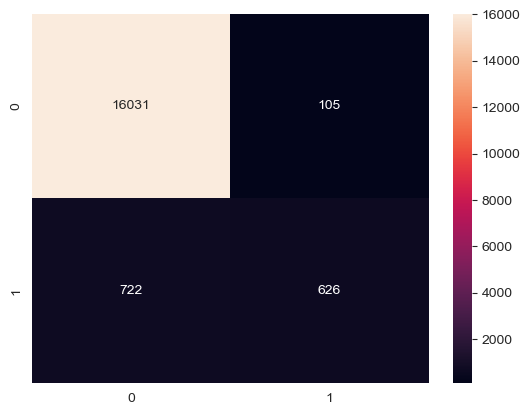

In [ ]:
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt="d")
plt.show()

In [ ]:
# feature importance
feat_imp_df = pd.DataFrame({
    "feature": X_train.columns.tolist(),
    "importance": cbc_model.feature_importances_
})
feat_imp_df.sort_values(by="importance", ascending=False)

,feature,importance
19,review_comment_message,23.489686
17,review_score,16.226238
1,order_approved_at,7.398517
0,order_purchase_timestamp,7.361028
3,customer_state,6.657962
2,customer_city,6.105555
29,order_approved_week,3.704705
5,seller_id,3.233623
4,product_id,3.221287
30,season,3.006766


In [ ]:
cbc_model_full = cb.CatBoostClassifier(
    cat_features=cat_cols,
    text_features=text_cols,
    n_estimators=10000,
    max_depth=8,
    learning_rate=0.01,
    eval_metric='Accuracy',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=1000,
    verbose=100,
    random_seed=42,
)
cbc_model_full.fit(X, y)

0:	learn: 0.9345101	total: 34.8ms	remaining: 5m 47s
100:	learn: 0.9380105	total: 3.27s	remaining: 5m 20s
200:	learn: 0.9409389	total: 5.89s	remaining: 4m 47s
300:	learn: 0.9440733	total: 9.07s	remaining: 4m 52s
400:	learn: 0.9458464	total: 11.7s	remaining: 4m 40s
500:	learn: 0.9471505	total: 14.2s	remaining: 4m 29s
600:	learn: 0.9480999	total: 16.5s	remaining: 4m 18s
700:	learn: 0.9488435	total: 18.7s	remaining: 4m 8s
800:	learn: 0.9491981	total: 20.9s	remaining: 4m
900:	learn: 0.9497586	total: 23s	remaining: 3m 52s
1000:	learn: 0.9502391	total: 25.2s	remaining: 3m 46s
1100:	learn: 0.9507767	total: 27.3s	remaining: 3m 40s
1200:	learn: 0.9512114	total: 29.2s	remaining: 3m 34s
1300:	learn: 0.9515546	total: 31.3s	remaining: 3m 29s
1400:	learn: 0.9518978	total: 33.3s	remaining: 3m 24s
1500:	learn: 0.9521494	total: 35.2s	remaining: 3m 19s
1600:	learn: 0.9525384	total: 37.3s	remaining: 3m 15s
1700:	learn: 0.9526871	total: 39.4s	remaining: 3m 12s
1800:	learn: 0.9529845	total: 41.5s	remaining:

## Submission

In [ ]:
# test_df = ori_test_df.copy()
test_final_df = test_df.copy()
test_final_df = create_feature(test_final_df)
test_final_df = test_final_df.loc[:, X.columns.tolist()]
test_final_df.loc[test_final_df.product_category_name.isnull(), "product_category_name"] = "unknown"
test_final_df["review_comment_title"].fillna("", inplace=True)
test_final_df["review_comment_message"].fillna("", inplace=True)
test_final_df.head()

,order_purchase_timestamp,order_approved_at,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,...,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,season,product_volume,product_weight_ratio
0,2017-11-18 12:29:57,2017-11-18 12:46:08,goiania,GO,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,1,credit_card,...,12,46,11.0,18.0,5.0,12.0,46,Fall,880.0,0.056818
1,2018-06-02 17:13:12,2018-06-02 20:12:23,viamao,RS,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,1,credit_card,...,17,22,6.0,2.0,5.0,20.0,22,Summer,2058.0,0.097182
2,2018-01-08 11:01:30,2018-01-09 07:24:03,campinas,SP,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,1,wallet,...,11,2,1.0,9.0,1.0,7.0,2,Winter,10000.0,0.100000
3,2017-03-10 10:24:46,2017-03-10 10:24:46,santana de parnaiba,SP,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,1,credit_card,...,10,10,3.0,10.0,4.0,10.0,10,Spring,48000.0,0.186458
4,2017-12-02 10:04:07,2017-12-05 04:13:30,aripuana,MT,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,1,wallet,...,10,48,12.0,5.0,1.0,4.0,49,Winter,38080.0,0.060425


In [ ]:
test_final_df.isnull().sum()

order_purchase_timestamp      0
order_approved_at             7
customer_city                 0
customer_state                0
product_id                    0
seller_id                     0
price                         0
shipping_charges              0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
product_category_name         0
product_weight_g             10
product_length_cm            10
product_height_cm            10
product_width_cm             10
review_score                341
review_comment_title          0
review_comment_message        0
order_purchase_month          0
order_purchase_day            0
order_purchase_dayofweek      0
order_purchase_hour           0
order_purchase_week           0
order_approved_month          7
order_approved_day            7
order_approved_dayofweek      7
order_approved_hour           7
order_approved_week           7
season                        0
product_

In [ ]:
test_final_df.loc[test_final_df.order_approved_at.isnull(), "order_approved_at"].index

Int64Index([309, 4699, 16372, 21613, 28627, 30628, 36653], dtype='int64')

In [ ]:
test_final_df.loc[test_final_df.order_approved_at.isnull(), "order_approved_at"] = \
    test_final_df.loc[test_final_df.order_approved_at.isnull(), "order_purchase_timestamp"] + \
    (test_final_df.order_approved_at - test_final_df.order_purchase_timestamp).mean()

In [ ]:
test_final_df.loc[[309, 4699, 16372, 21613, 28627, 30628, 36653], :]

,order_purchase_timestamp,order_approved_at,customer_city,customer_state,product_id,seller_id,price,shipping_charges,payment_sequential,payment_type,...,order_purchase_hour,order_purchase_week,order_approved_month,order_approved_day,order_approved_dayofweek,order_approved_hour,order_approved_week,season,product_volume,product_weight_ratio
309,2017-02-18 22:49:19,2017-02-19 09:17:45.739940426,rio de janeiro,RJ,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,1,wallet,...,22,7,NaN,NaN,NaN,NaN,<NA>,Winter,1512.0,0.165344
4699,2017-02-18 12:45:31,2017-02-18 23:13:57.739940426,novo hamburgo,RS,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,1,wallet,...,12,7,NaN,NaN,NaN,NaN,<NA>,Winter,12012.0,0.083916
16372,2017-02-18 22:49:19,2017-02-19 09:17:45.739940426,rio de janeiro,RJ,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,1,wallet,...,22,7,NaN,NaN,NaN,NaN,<NA>,Winter,1512.0,0.165344
21613,2017-02-19 01:28:47,2017-02-19 11:57:13.739940426,sao paulo,SP,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,1,wallet,...,1,7,NaN,NaN,NaN,NaN,<NA>,Winter,6072.0,0.279974
28627,2017-01-19 12:48:08,2017-01-19 23:16:34.739940426,santos,SP,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,1,wallet,...,12,3,NaN,NaN,NaN,NaN,<NA>,Winter,8736.0,0.080128
30628,2017-02-18 17:15:03,2017-02-19 03:43:29.739940426,sao jose de ribamar,MA,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,1,wallet,...,17,7,NaN,NaN,NaN,NaN,<NA>,Winter,15750.0,0.076190
36653,2017-02-18 13:29:47,2017-02-18 23:58:13.739940426,sao paulo,SP,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,1,wallet,...,13,7,NaN,NaN,NaN,NaN,<NA>,Winter,39200.0,0.079082


In [ ]:
test_final_df.fillna(-1, inplace=True)
test_final_df.isnull().sum()

order_purchase_timestamp    0
order_approved_at           0
customer_city               0
customer_state              0
product_id                  0
seller_id                   0
price                       0
shipping_charges            0
payment_sequential          0
payment_type                0
payment_installments        0
payment_value               0
product_category_name       0
product_weight_g            0
product_length_cm           0
product_height_cm           0
product_width_cm            0
review_score                0
review_comment_title        0
review_comment_message      0
order_purchase_month        0
order_purchase_day          0
order_purchase_dayofweek    0
order_purchase_hour         0
order_purchase_week         0
order_approved_month        0
order_approved_day          0
order_approved_dayofweek    0
order_approved_hour         0
order_approved_week         0
season                      0
product_volume              0
product_weight_ratio        0
dtype: int

In [ ]:
y_test_pred = cbc_model_full.predict(test_final_df)
y_test_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [ ]:
submission_df = pd.DataFrame({
    "order_id": ori_test_df.order_id,
    "is_late": y_test_pred
})
submission_df.head()

,order_id,is_late
0,u6rPMRAYIGig,0
1,ohY8f4FEbX19,0
2,I28liQek73i2,0
3,bBG1T89mlY8W,0
4,CYxJJSQS8Lbo,0


In [ ]:
submission_df.is_late.value_counts()

0    36243
1     2036
Name: is_late, dtype: int64

In [ ]:
submission_df.to_csv("submissions/submission_5_1.csv", index=False)